In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantity import * 
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize()
fig_dir, data_dir = './figs', './data'

In [38]:
n = 10 # 10
t = 10  
r = 50 # 100

dt = t/r
# H_model = 'MFI'
hx, hy, Jx = 1, 0.9, 0.8
print(f't={t}, r={r}, dt={dt}')

# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
ob_op = z1
obs = ob_op.to_matrix()
complete_fnorm = 2**(-n/2)*np.linalg.norm(obs, ord='fro')

t=10, r=50, dt=0.2


In [39]:
qmfi = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qmfi_xx_even = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[::2]], num_qubits=n).simplify()
qmfi_xx_odd = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[1::2]], num_qubits=n).simplify()
qmfi_x_terms = SparsePauliOp.from_sparse_list([*qmfi.x_tuples], num_qubits=n).simplify()
qmfi_y_terms = qmfi.y_terms
qmfi_H_list = [qmfi_x_terms, qmfi_y_terms, qmfi_xx_even, qmfi_xx_odd] 
qmfi_H_ordered = sum(qmfi_H_list)
qmfi_U_dt_ideal = expH(sum(qmfi_H_ordered), dt, use_jax=False)
qmfi_U_dt_appro = pf(qmfi_H_ordered, dt, 1, 1)

qmfi_ideal_ops = [matrix_power(qmfi_U_dt_ideal, i) for i in range(r+1)]
qmfi_trott_ops = [matrix_power(qmfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qmfi_ideal_states = [qmfi_ideal_ops[i]@init_state for i in range(r+1)]
qmfi_trott_states = [qmfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qmfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_trott_ops]
qmfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_ideal_ops]
print('evoluate expvals...')
qmfi_ideal_expvals = [expect_value(obs, qmfi_ideal_states[i]) for i in range(r+1)]
qmfi_trott_expvals = [expect_value(obs, qmfi_trott_states[i]) for i in range(r+1)]

qmfi_ops = dt*sum(qmfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


In [40]:
qtfi = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
qtfi_xx_even = SparsePauliOp.from_sparse_list([*qtfi.xx_tuples[::2]], num_qubits=n).simplify()
qtfi_xx_odd = SparsePauliOp.from_sparse_list([*qtfi.xx_tuples[1::2]], num_qubits=n).simplify()
qtfi_x_terms = SparsePauliOp.from_sparse_list([*qtfi.x_tuples], num_qubits=n).simplify()
qtfi_y_terms = qtfi.y_terms
qtfi_H_list = [qtfi_x_terms, qtfi_y_terms, qtfi_xx_even, qtfi_xx_odd] 
qtfi_H_ordered = sum(qtfi_H_list)
qtfi_U_dt_ideal = expH(sum(qtfi_H_ordered), dt, use_jax=False)
qtfi_U_dt_appro = pf(qtfi_H_ordered, dt, 1, 1)

qtfi_ideal_ops = [matrix_power(qtfi_U_dt_ideal, i) for i in range(r+1)]
qtfi_trott_ops = [matrix_power(qtfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qtfi_ideal_states = [qtfi_ideal_ops[i]@init_state for i in range(r+1)]
qtfi_trott_states = [qtfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qtfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qtfi_trott_ops]
qtfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qtfi_ideal_ops]
print('evoluate expvals...')
qtfi_ideal_expvals = [expect_value(obs, qtfi_ideal_states[i]) for i in range(r+1)]
qtfi_trott_expvals = [expect_value(obs, qtfi_trott_states[i]) for i in range(r+1)]

qtfi_ops = dt*sum(qtfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


In [41]:
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

w_thres = n
qmfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qmfi_ops, threshold=w_thres, nprocs=4)
qmfi_res = qmfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
qmfi_res = np.array(qmfi_res)
# res = res / res[0].sum()

qtfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qtfi_ops, threshold=w_thres+1, nprocs=4)
qtfi_res = qtfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
qtfi_res = np.array(qtfi_res)

qmfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qmfi_sim.evo_obs]
qtfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qtfi_sim.evo_obs]

100%|██████████| 50/50 [00:00<00:00, 174.49it/s]


In [42]:
sub_dim = 3
qmfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qmfi_trott_states]
qtfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qtfi_trott_states]
qmfi_magic = [operator_magic(obs) for obs in qmfi_sim.evo_obs]
qtfi_magic = [operator_magic(obs) for obs in qtfi_sim.evo_obs]

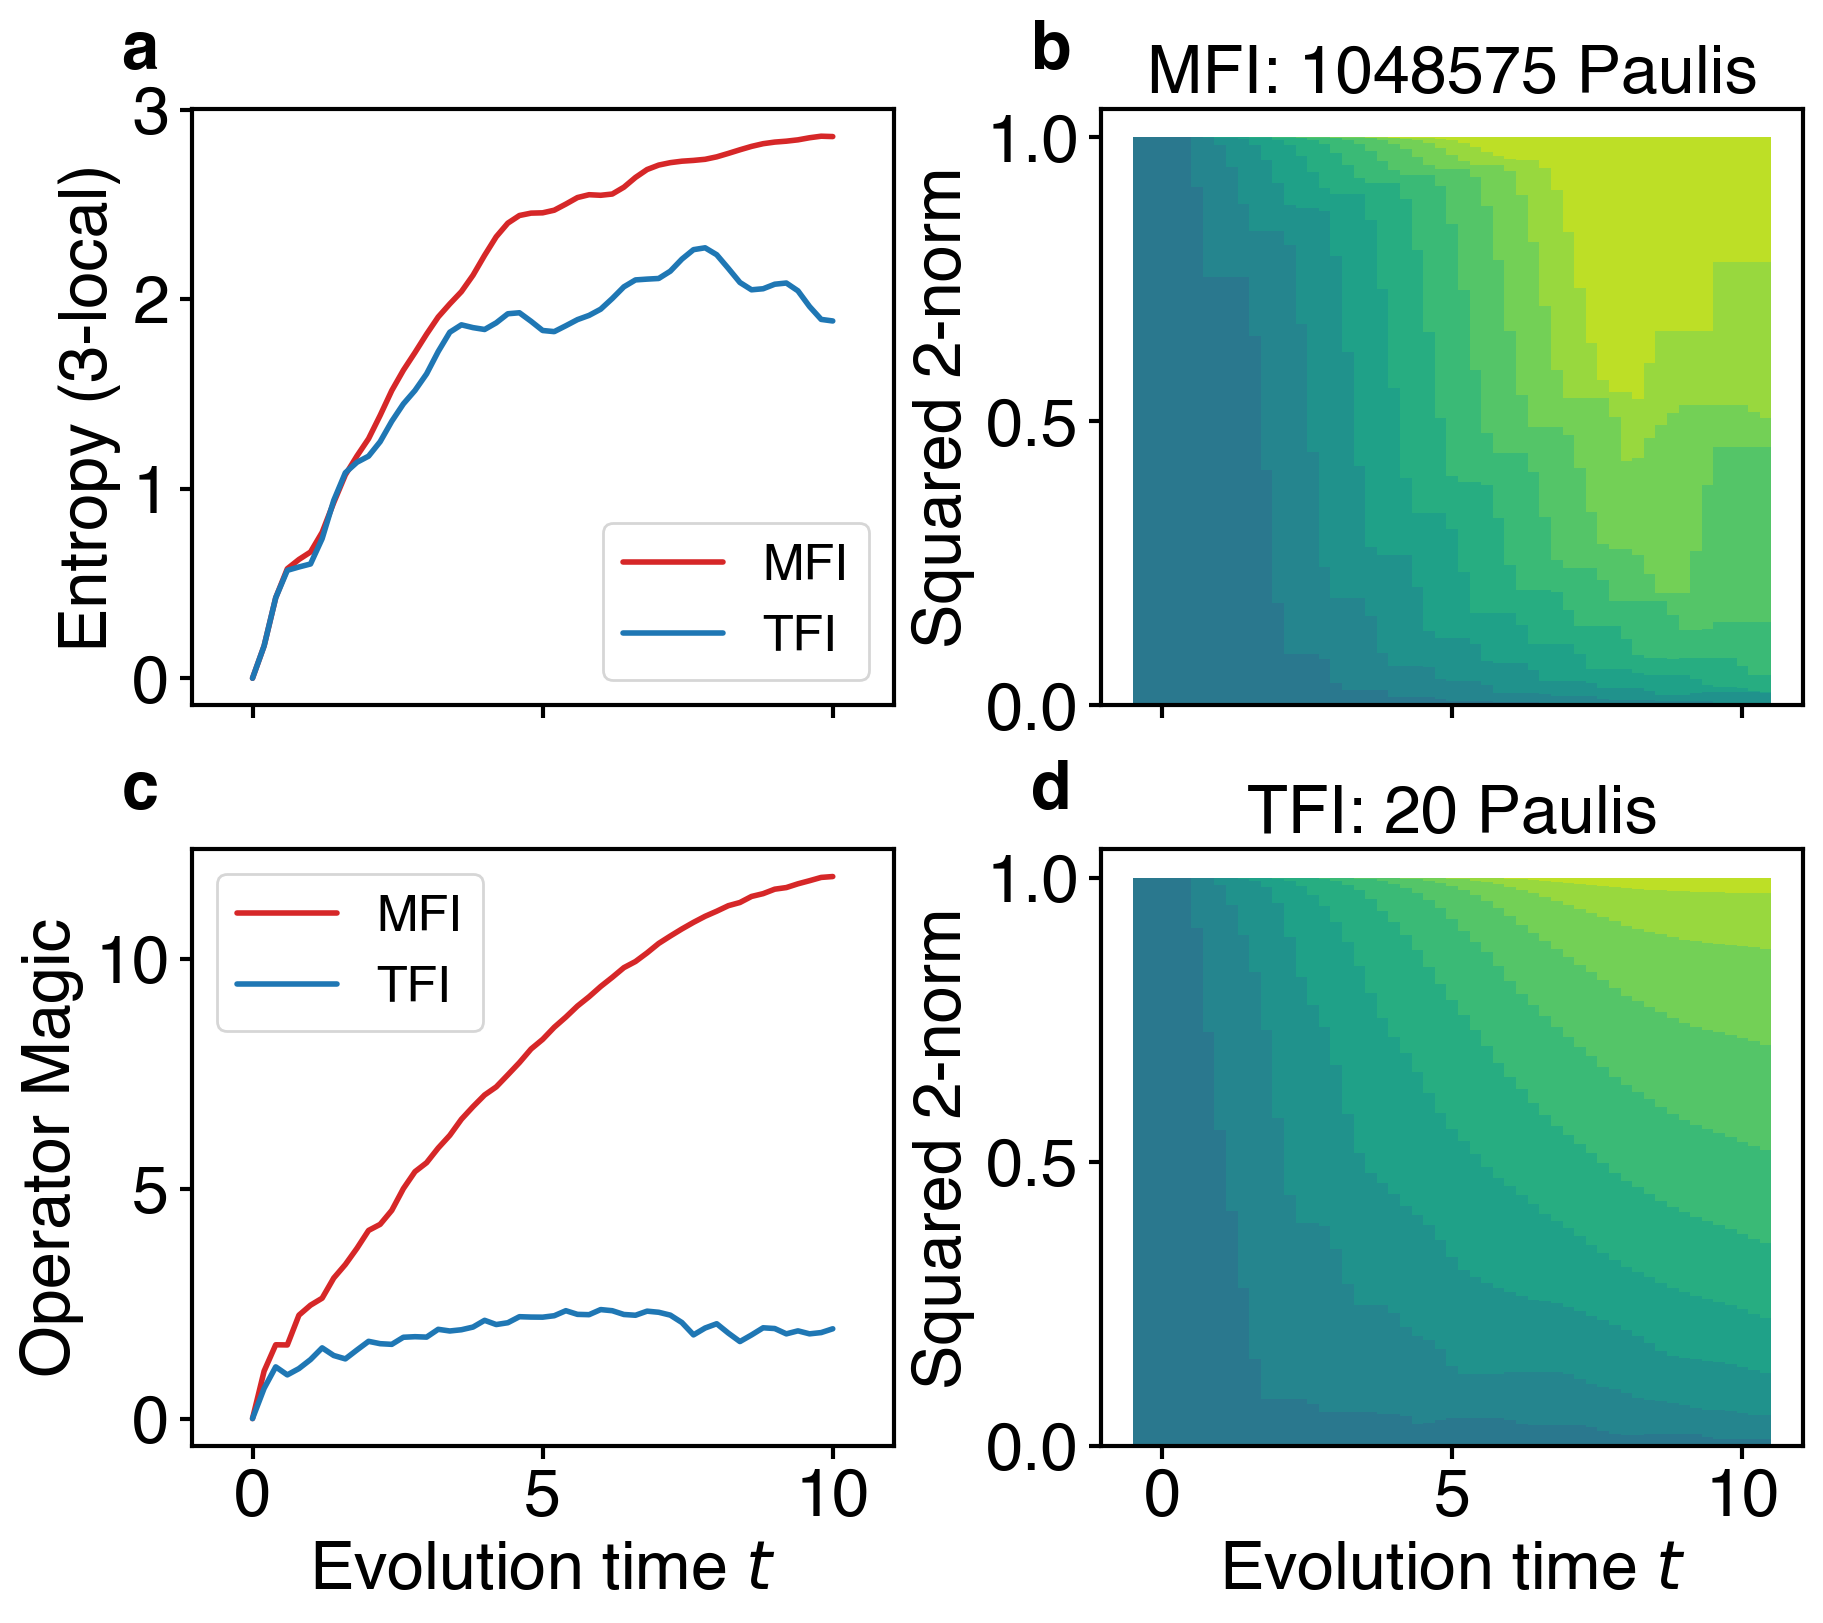

In [44]:
t_list = [i*dt for i in range(r+1)]
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained')
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
for w in range(n, 0, -1):
    qmfi_norm2_distr = [sum(qmfi_norm_weight_steps[i][:w]) for i in range(len(t_list))]
    qtfi_norm2_distr = [sum(qtfi_norm_weight_steps[i][:w]) for i in range(len(t_list))]
    bars = axes[0,1].bar(t_list, qtfi_norm2_distr, 1, color=colors[w-1], label=f'w<={w}')
    bars = axes[1,1].bar(t_list, qmfi_norm2_distr, 1, color=colors[w-1], label=f'w<={w}')
axes[0,1].set_ylabel(r'Squared 2-norm'); 
axes[0,1].set_title(f'MFI: {qmfi_sim.evo_obs[-1].size()} Paulis') 
axes[1,1].set_title(f'TFI: {qtfi_sim.evo_obs[-1].size()} Paulis') 
axes[1,1].set_ylabel(r'Squared 2-norm') # axes[1,0].legend(loc='upper right')
axes[1,1].set_xlabel(rf'Evolution time $t$')

axes[0,0].plot(t_list, qmfi_entangle_entropy3, label='MFI', c='tab:red')
axes[0,0].plot(t_list, qtfi_entangle_entropy3, label='TFI', c='tab:blue')
axes[0,0].set_ylabel(f'Entropy ({sub_dim}-local)'); axes[0,0].legend()
axes[1,0].plot(t_list, qmfi_magic, label='MFI', c='tab:red')
axes[1,0].plot(t_list, qtfi_magic, label='TFI', c='tab:blue')
axes[1,0].set_ylabel('Operator Magic'); axes[1,0].legend()
axes[1,0].set_xlabel(rf'Evolution time $t$')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/Magic_Entangle_n={n}_t={t}_r={r}.pdf', bbox_inches='tight')

In [28]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim1.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim1.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 200
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in haar_states] for i, ob in enumerate(evo_obs)]
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in haar_states] for i, ob in enumerate(ideal_obs)]

[0.0, 1.1099614042939736e-15, 2.4310592870133338e-15, 3.211756068922338e-15, 3.625504831580959e-06, 2.7520867425055504e-05, 0.00011552900866601548, 0.00035190348078254646, 0.000863518122656585, 0.0018024504769196222, 0.00331242105204725, 0.0055044899999427245, 0.008489040035058647, 0.012509431919239462, 0.018152751143472343, 0.02645659459916393, 0.03868450896072565, 0.05583793946222428, 0.07822271357897453, 0.10526546243726866, 0.13563862330988802, 0.16770438377679917, 0.2001650657078882, 0.2326264365241849, 0.26569923461427625, 0.30046379923058736, 0.3376038197601632, 0.3768612071557347, 0.4171994150322768, 0.4574292167037512, 0.49674491029654466, 0.5348334422301222, 0.5716183058928728, 0.6069467012638904, 0.64049151092769, 0.671902488296779, 0.7010267218346371, 0.7279949568041231, 0.7531141078952582, 0.7766656429828658, 0.7987589425075882, 0.8193193098428143, 0.8381863201769878, 0.8552435378993393, 0.8705121994606081, 0.8841828045820721, 0.8965906643327135, 0.9081508089114099, 0.9192

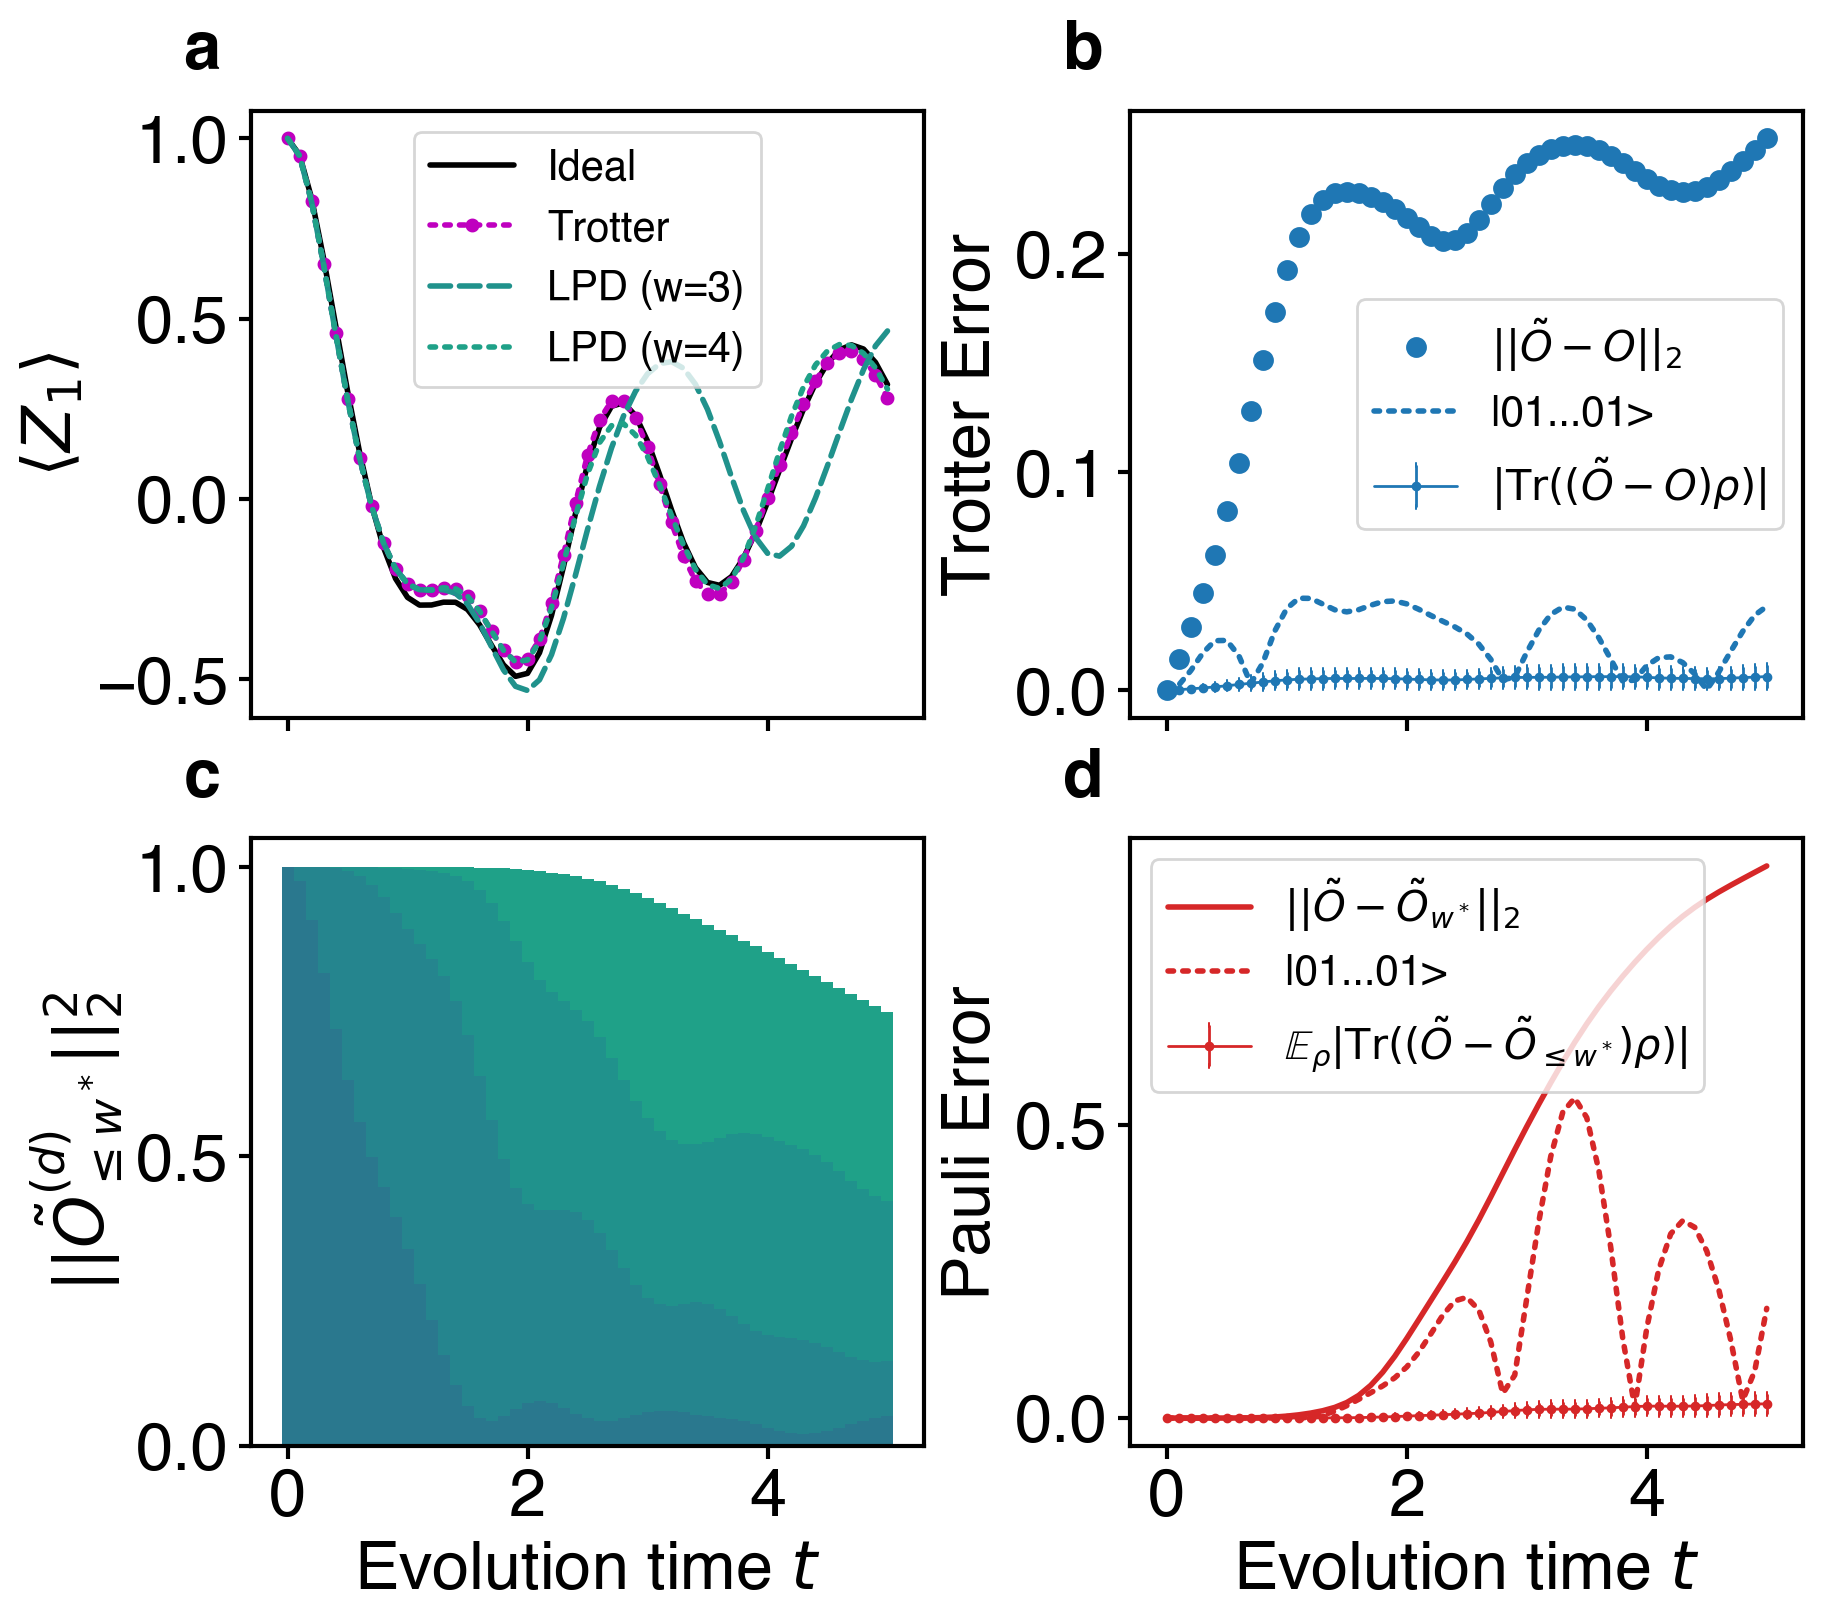

In [ ]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0,0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize='small', ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|01...01>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|01...01>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')


for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/magic_entangle_n={n}_t={t}_r={r}_{init_state_str[:4]}.pdf', bbox_inches='tight')